In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline, BSpline
from eQIF_utils import *

In [14]:
# Plot the results with custom font sizes for better readability
plt.rcParams.update({
'font.size': 20,          # Controls default text size
'axes.titlesize': 20,     # Title font size
'axes.labelsize': 20,     # X/Y label font size
'xtick.labelsize': 18,    # X tick labels
'ytick.labelsize': 18,    # Y tick labels
'legend.fontsize': 14,    # Legend font size
})

### Hysteresis heatmap in (a , $I_{ext}$) plane

In [ ]:
# Define parameter ranges for hysteresis boundaries
range_hysteresis = 60
a_range_boundaries = np.round(np.linspace(0, 18, range_hysteresis),3) 
Iext_range_boundaries = np.round(np.linspace(0, 130, range_hysteresis),3)

# Define time array for hysteresis boundaries (NOTE: they have to be given in milliseconds)
dt = 0.01
up_time_max = 20000
step_time = 1000
duration_boundaries = up_time_max + step_time*len(Iext_range_boundaries)
time_array_boundaries = np.arange(0, duration_boundaries + dt/2, dt)

# Generate I_steps to find hysteresis boundaries for different a values
I_steps = np.zeros(len(time_array_boundaries))
up_time = (time_array_boundaries <= up_time_max)
I_steps[up_time] = Iext_range_boundaries[-1]*time_array_boundaries[up_time]/up_time_max
down_time = (time_array_boundaries > up_time_max)
I_steps[down_time] = np.concatenate([i_value*np.ones(int(step_time/dt)) for i_value in Iext_range_boundaries[::-1]])
plt.plot(time_array_boundaries, I_steps)
plt.show()

In [ ]:
# Find hysteresis boundaries for different a values
start_boundary, stop_boundary = hysteresis_boundaries_Iext_vs_a(time_array_boundaries, a_range_boundaries, b_value=50, I_stim=I_steps, v0=-25, Iw0=500)

In [ ]:
# Stop boundary may result in duplicate x-values due to the nature of the hysteresis curve, which can cause issues with spline interpolation. 
# This effect can be smoothed by aggregating duplicate x-values before applying the spline.

# Smooth stop_boundary by aggregating duplicate x-values before spline
x = stop_boundary[:, 0]
y = stop_boundary[:, 1]

# Aggregate duplicate x values by averaging corresponding y values
ux, inv = np.unique(x, return_inverse=True)
y_agg = np.array([y[inv == i].mean() for i in range(len(ux))])

# Choose spline degree safely: k <= len(ux)-1 and at least 1 when possible
k = min(3, max(1, len(ux) - 1))

if len(ux) < 2:
    # Not enough distinct points to interpolate: plot raw points
    raise ValueError("Not enough distinct points to interpolate")
else:
    xnew = np.linspace(ux[0], ux[-1], 500)
    try:
        spl = make_interp_spline(ux, y_agg, k=k)
        power_smooth = spl(xnew)
    except Exception:
        # Fallback to linear interpolation if spline fails
        power_smooth = np.interp(xnew, ux, y_agg)

In [ ]:
# Define parameters grid for frequency heatmap to superimpose on hysteresis boundaries
# NOTE: parameters range can be different from the one used to find hysteresis boundaries, 
# but it should cover the same area of the parameter space to be able to superimpose the results.
# It was done since the frequency heatmap is more computationally expensive, so we can use a coarser grid for it.
range_heatmap = 70
a_range_heatmap = np.round(np.linspace(0, 20, range_heatmap),3) 
Iext_range_heatmap = np.round(np.linspace(0, 130, 60),3)
parameters_grid_v2 = [(a, I) for a in a_range_heatmap for I in Iext_range_heatmap]
I_vs_a_results = {}

# (NOTE: they have to be given in milliseconds)
dt = 0.01
duration = 20000
t_start = duration - 4000
t_end = duration - 1000
time_array = np.arange(0, duration + dt/2, dt)

for i, (a_val, i_val) in enumerate(parameters_grid_v2):
    I_injected = np.ones(len(time_array))*i_val
    
    V_sim, Iw_sim, spikes_sim = variable_current_sim(time_array, I_injected, a_val, b=50, v0=-25, Iw0=500)
    
    avg_f = compute_rate(spikes_sim, t_start, t_end)
    I_vs_a_results[(a_val, i_val)] = avg_f

avg_frequencies = []

for (a_val, i_val) in parameters_grid_v2:
    f_value = I_vs_a_results[(a_val, i_val)]
    avg_frequencies.append(f_value)
avg_frequencies = np.array(avg_frequencies).reshape(len(a_range_heatmap), len(Iext_range_heatmap))

In [ ]:
# Overlay original points lightly
plt.figure(figsize=(8, 6))
plt.plot(stop_boundary[:, 0], stop_boundary[:, 1], 'g', lw=2, alpha=0.5)
plt.plot(xnew, power_smooth, '--g', lw=5)
plt.plot(start_boundary[:, 0], start_boundary[:, 1], '--g', lw=5)
plt.imshow(avg_frequencies, origin='lower', cmap='turbo', extent=(Iext_range_heatmap[0], Iext_range_heatmap[-1], a_range_heatmap[0], a_range_heatmap[-1]), aspect='auto')
plt.colorbar(label='f (Hz)')
plt.xlim(1, 130)
plt.xlabel(r'$I_{ext}$ (pA)')
plt.ylabel('a (nS)')
plt.savefig("Figure_9b.svg", dpi=300, bbox_inches='tight', format='svg')
plt.show()

### Plot hysteresis frequency heatmap for different b values 

In [ ]:
# Define simulation parameters for frequency heatmap (NOTE: times have to be given in milliseconds)
duration = 20000  
dt = 0.01  
# Define window to compute frequency (NOTE: it has to be given in milliseconds)
t_start = duration - 4000
t_end = duration - 1000
time_array = np.arange(0, duration + dt/2, dt)

n_values = 80
Iext_range = np.round(np.linspace(0, 180, n_values),2)
b_range = np.round(np.linspace(0, 150, n_values),2) #np.round(np.linspace(0, 150, 70),2)

# Compute frequency heatmap for different Iext and b values, keeping a fixed 
mat_frequency_UP = np.zeros((len(Iext_range), len(b_range)))
mat_frequency_DOWN = np.zeros((len(Iext_range), len(b_range)))

for i, Iext in enumerate(Iext_range):
    for j, b_val in enumerate(b_range):
        _, _, spikes_sim_UP = variable_current_sim(time_array, np.ones(len(time_array))*Iext, a=10., b=b_val, v0=-25, Iw0=200)
        _, _, spikes_sim_DOWN = variable_current_sim(time_array, np.ones(len(time_array))*Iext, a=10., b=b_val, v0=-65, Iw0=-200)

        f_sim_UP = compute_rate(spikes_sim_UP, t_start, t_end)
        f_sim_DOWN = compute_rate(spikes_sim_DOWN, t_start, t_end)

        mat_frequency_UP[i, j] = f_sim_UP
        mat_frequency_DOWN[i, j] = f_sim_DOWN


# Build a binary mask: 1 where states differ, 0 where they're the same 
difference = mat_frequency_UP - mat_frequency_DOWN
threshold = 1.0  # Hz 
hysteresis_mask = (np.abs(difference) > threshold).astype(float)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the UP frequency heatmap
im = ax.imshow(mat_frequency_UP, origin="lower", cmap="turbo", extent=[b_range[0], b_range[-1], Iext_range[0], Iext_range[-1]], aspect="auto")
plt.colorbar(im, ax=ax, label="f (Hz)")

# Superimpose the hysteresis boundary
ax.contour(b_range, Iext_range, hysteresis_mask,
    levels=[0.5],          # boundary sits at the 0.5 iso-line of the mask
    colors="green", linewidths=4, linestyles="--" )

ax.set_xlabel("b (pA)")
ax.set_ylabel("$I_{ext}$ (pA)")
plt.savefig("Figure_9a.svg", dpi=300, bbox_inches='tight', format='svg')
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(mat_frequency_UP, origin='lower', cmap='turbo', extent=(b_range[0], b_range[-1], Iext_range[0], Iext_range[-1]), aspect='auto')
plt.colorbar(label='f (Hz)')
plt.xlabel('b (pA)')
plt.ylabel('$I_{ext}$ (pA)')
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(mat_frequency_DOWN, origin='lower', cmap='turbo', extent=(b_range[0], b_range[-1], Iext_range[0], Iext_range[-1]), aspect='auto')
plt.colorbar(label='f (Hz)')
plt.xlabel('b (pA)')
plt.ylabel('$I_{ext}$ (pA)')
plt.show()

# Check where UP and DOWN matrices are different 
difference = mat_frequency_UP - mat_frequency_DOWN 
plt.figure(figsize=(8, 6))
plt.imshow(difference, origin='lower', cmap='bwr', extent=(b_range[0], b_range[-1], Iext_range[0], Iext_range[-1]), aspect='auto')
plt.colorbar(label='f_UP - f_DOWN (Hz)')

### Plot hysteresis loop

In [19]:
# Define time parameters for simulations and analysis
# (NOTE: they have to be given in milliseconds)
dt = 0.01
duration = 25000
time_array = np.arange(0, duration + dt/2, dt)
t_start = duration - 5000
t_end = duration - 1000

# Simulate with different Iext value to show the hysteresis effect in the frequency response of the neuron
# Changing initial conditions to show the hysteresis effect in the frequency response of the neuron
Iext_range = np.round(np.linspace(30, 100, 150),2)

up_frequency = []
down_frequency = []

for Iext in Iext_range:
    V_sim_up, Iw_sim_up, spikes_sim_up = variable_current_sim(time_array, np.ones(len(time_array))*Iext, a=10, b=100, v0=-25, Iw0=100)
    V_sim_down, Iw_sim_down, spikes_sim_down = variable_current_sim(time_array, np.ones(len(time_array))*Iext, a=10, b=100, v0=-25, Iw0=-100)

    f_up = compute_rate(spikes_sim_up, t_start, t_end)
    f_down = compute_rate(spikes_sim_down, t_start, t_end)

    up_frequency.append(f_up)
    down_frequency.append(f_down)

up_frequency = np.array(up_frequency)
down_frequency = np.array(down_frequency)

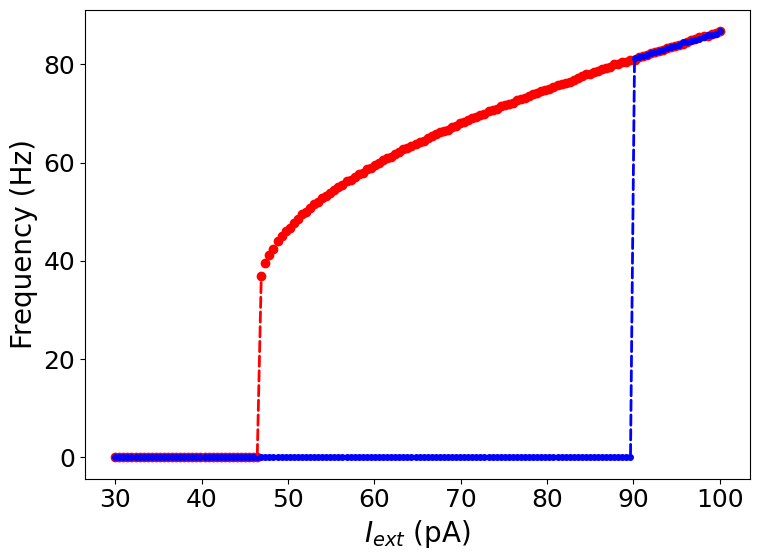

In [22]:
plt.figure(figsize=(8,6))
plt.plot(Iext_range, up_frequency, 'or', markersize=6)
plt.plot(Iext_range, down_frequency, 'ob', markersize=4)

# Define arrow to show jump from 0 to >0 for the ascending curve
threshold = 0.1  
for i in range(len(up_frequency)-1):
    if up_frequency[i] < threshold and up_frequency[i+1] > threshold:
        plt.annotate('', xy=(Iext_range[i+1], up_frequency[i+1]),
                    xytext=(Iext_range[i], up_frequency[i]),
                    arrowprops=dict(arrowstyle='-', color='red', lw=2, linestyle='--'))
        break

# Define arrow to show jump from >0 to 0 for the descending curve
for i in range(len(down_frequency)-1):
    if down_frequency[i] < threshold and down_frequency[i+1] > threshold:
        plt.annotate('', xy=(Iext_range[i+1], down_frequency[i+1]),
                    xytext=(Iext_range[i], down_frequency[i]),
                    arrowprops=dict(arrowstyle='-', color='blue', lw=2, linestyle='--'))
        break

plt.xlabel('$I_{ext}$ (pA)')
plt.ylabel('Frequency (Hz)')
plt.tight_layout()
plt.savefig("Figure_2b.svg", dpi=300, format='svg')
plt.show()

In [15]:
# Define time array for hysteresis boundaries (NOTE: they have to be given in milliseconds)
dt = 0.001
half_length = 1500
half_time = np.arange(0, half_length, dt)

# Generate ramp current
I_ramp_up = 0.1 * half_time
I_ramp_down = -0.1 * half_time + I_ramp_up[-1]
I_ramp = np.concatenate([I_ramp_up, I_ramp_down])

# Simulate with ramp current to show the hysteresis effect in the frequency response of the neuron
time_array_ramp = np.arange(0, 2 * half_length, dt)
V_sim, Iw_sim, spikes_sim = variable_current_sim(time_array_ramp, I_ramp, a=10, b=100, v0=-62, Iw0=0)

if len(spikes_sim) > 1:
    isis = np.diff(spikes_sim)
    instantaneous_freq = np.zeros(len(time_array_ramp))
    for i in range(1, len(spikes_sim)):
        mask = (time_array_ramp >= spikes_sim[i - 1]) & (time_array_ramp < spikes_sim[i])
        instantaneous_freq[mask] = 1 / isis[i - 1]
else:
    instantaneous_freq = np.zeros(len(time_array_ramp))

# Split time/current arrays into ramp-up and ramp-down segments
n_half = len(half_time)
t_up   = time_array_ramp[:n_half]
I_up   = I_ramp[:n_half]
t_down = time_array_ramp[n_half:]
I_down = I_ramp[n_half:]

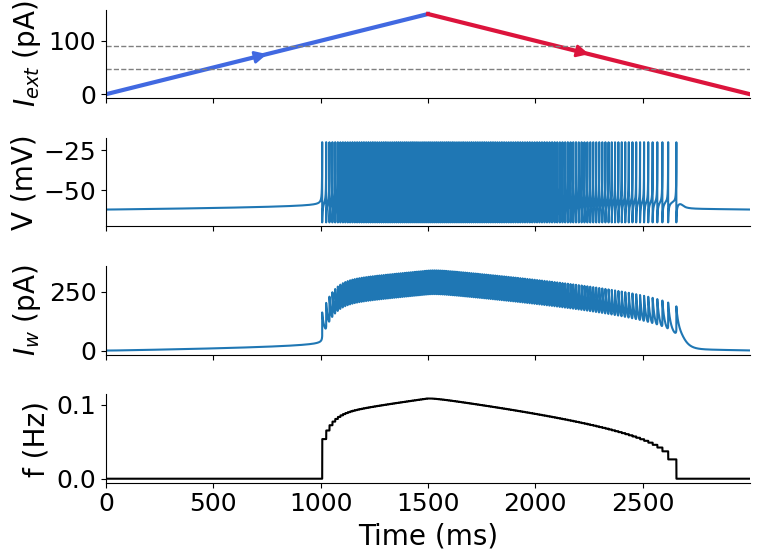

In [18]:
# Arrow position: midpoint of each segment
def add_arrow(ax, t_seg, I_seg, color):
    """Draw a filled arrow at the midpoint of a curve to indicate direction."""
    mid = len(t_seg) // 2
    # Arrow drawn from mid-1 to mid (short segment to get direction)
    dx = t_seg[mid] - t_seg[mid - 1]
    dy = I_seg[mid] - I_seg[mid - 1]
    ax.annotate(
        "",
        xy=(t_seg[mid], I_seg[mid]),
        xytext=(t_seg[mid - 1], I_seg[mid - 1]),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=2,
            mutation_scale=18,
        ),
    )

# Plot the results
fig, axs = plt.subplots(4, 1, figsize=(8, 6), sharex=True)

# --- Current plot with colored ramps and directional arrows ---
axs[0].plot(t_up,   I_up,   color='royalblue', lw=3)
axs[0].plot(t_down, I_down, color='crimson',   lw=3)
add_arrow(axs[0], t_up,   I_up,   color='royalblue')
add_arrow(axs[0], t_down, I_down, color='crimson')
axs[0].hlines(90, time_array_ramp[0], time_array_ramp[-1], color='gray', lw=1, ls='--')
axs[0].hlines(47, time_array_ramp[0], time_array_ramp[-1], color='gray', lw=1, ls='--')
axs[0].set_ylabel('$I_{ext}$ (pA)')

axs[1].plot(time_array_ramp, V_sim)
axs[1].set_ylabel('V (mV)')

axs[2].plot(time_array_ramp, Iw_sim)
axs[2].set_ylabel('$I_w$ (pA)')

axs[3].plot(time_array_ramp, instantaneous_freq, 'k')
axs[3].set_ylabel('f (Hz)')
axs[3].set_xlabel('Time (ms)')

for ax in axs:
    ax.set_xlim(time_array_ramp[0], time_array_ramp[-1])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Figure_2a.svg', dpi=300, format='svg')
plt.show()